In [1]:
# ── 라이브러리 ───────────────────────────────────────────────────────
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from src.data_loader import load_data

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False 

In [2]:
# ── 데이터 로드 ──────────────────────────────────────────────────────
df = load_data()
df['started_at']   = pd.to_datetime(df['started_at'])
df['ended_at']     = pd.to_datetime(df['ended_at'])
df['duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60
df = df[(df['duration_min'] > 0) & (df['duration_min'] <= 180)].copy()

print(f'총 레코드 수: {len(df):,}')

총 레코드 수: 28,165,708


In [3]:
# ── 1. 출발 / 도착 스테이션별 이용 수 ───────────────────────────────
start_cnt = (
    df.groupby(['start_station_id', 'start_station_name'])
      .size()
      .reset_index(name='depart_count')
      .sort_values('depart_count', ascending=False)
)
end_cnt = (
    df.groupby(['end_station_id', 'end_station_name'])
      .size()
      .reset_index(name='arrive_count')
      .sort_values('arrive_count', ascending=False)
)

print('=== 출발 Top 10 ===')
print(start_cnt.head(10).to_string(index=False))
print('\n=== 도착 Top 10 ===')
print(end_cnt.head(10).to_string(index=False))

=== 출발 Top 10 ===
start_station_id       start_station_name  depart_count
         6140.05          W 21 St & 6 Ave         97197
         5329.03    West St & Chambers St         95008
         6233.04 Pier 61 at Chelsea Piers         93454
         5788.13    Lafayette St & E 8 St         87364
         6492.08          9 Ave & W 33 St         80404
         6331.01          W 31 St & 7 Ave         80082
         6726.01         11 Ave & W 41 St         79974
         6948.10       Broadway & W 58 St         79257
         5905.12       Broadway & E 14 St         79033
         5905.14  University Pl & E 14 St         78158

=== 도착 Top 10 ===
end_station_id         end_station_name  arrive_count
       6140.05          W 21 St & 6 Ave         97329
       5329.03    West St & Chambers St         95166
       6233.04 Pier 61 at Chelsea Piers         93589
       5788.13    Lafayette St & E 8 St         87590
       6492.08          9 Ave & W 33 St         80853
       6331.01         

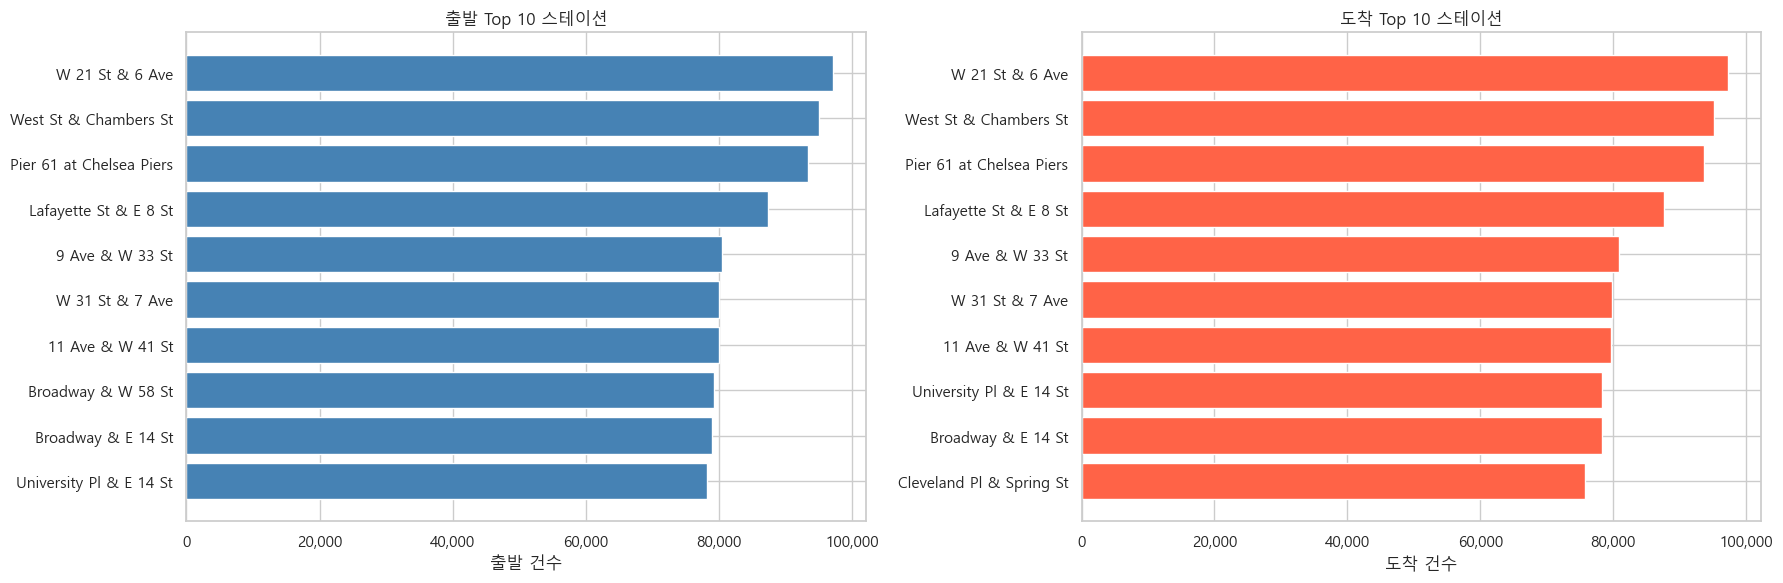

In [4]:
# ── 2. Top 10 출발 / 도착 스테이션 시각화 ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(start_cnt.head(10)['start_station_name'],
             start_cnt.head(10)['depart_count'],
             color='steelblue', edgecolor='white')
axes[0].set_title('출발 Top 10 스테이션')
axes[0].set_xlabel('출발 건수')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].barh(end_cnt.head(10)['end_station_name'],
             end_cnt.head(10)['arrive_count'],
             color='tomato', edgecolor='white')
axes[1].set_title('도착 Top 10 스테이션')
axes[1].set_xlabel('도착 건수')
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

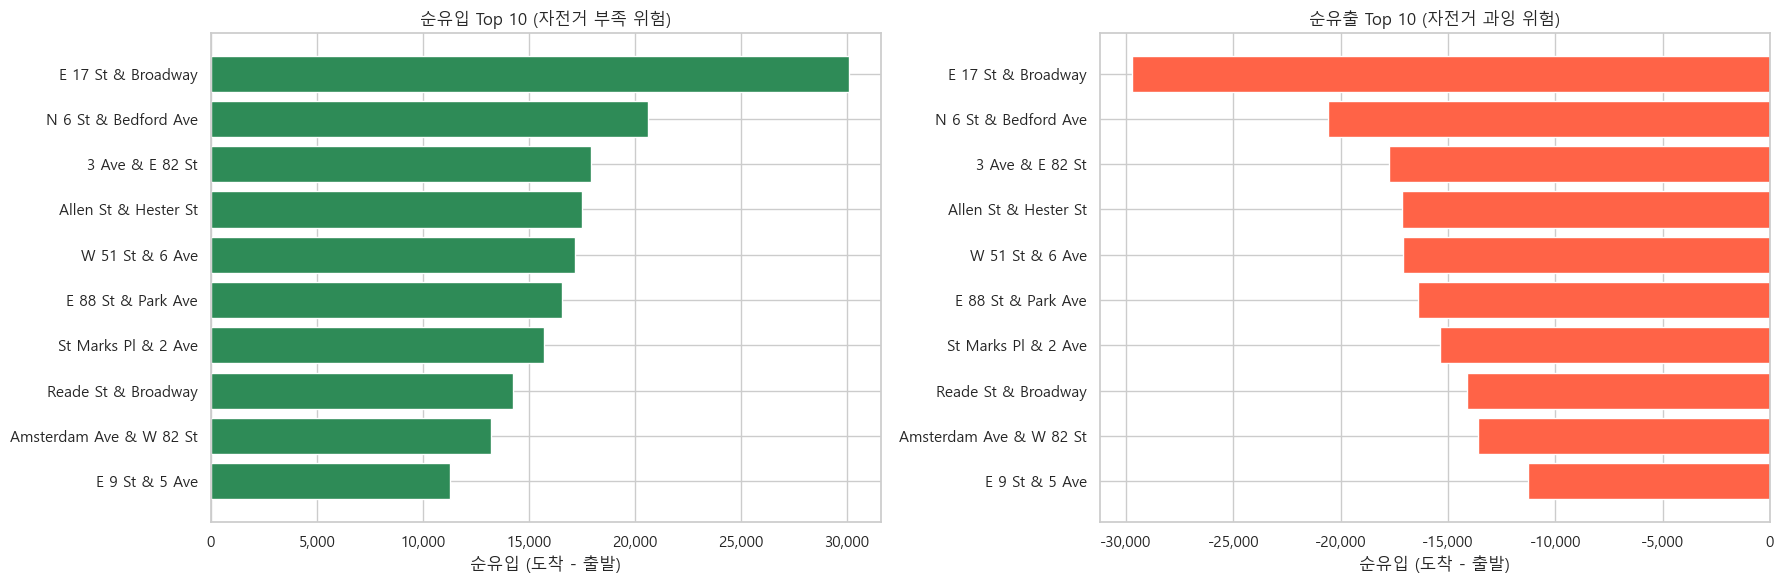

In [5]:
# ── 3. 스테이션별 순유입 (도착 - 출발) ──────────────────────────────
balance = pd.merge(
    start_cnt[['start_station_id', 'start_station_name', 'depart_count']],
    end_cnt[['end_station_id',   'end_station_name',   'arrive_count']],
    left_on='start_station_id', right_on='end_station_id',
    how='outer'
).fillna(0)

balance['net_inflow']   = balance['arrive_count'] - balance['depart_count']
balance['station_name'] = balance['start_station_name'].fillna(balance['end_station_name'])

top_inflow  = balance.nlargest(10, 'net_inflow')
top_outflow = balance.nsmallest(10, 'net_inflow')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(top_inflow['station_name'], top_inflow['net_inflow'],
             color='seagreen', edgecolor='white')
axes[0].set_title('순유입 Top 10 (자전거 부족 위험)')
axes[0].set_xlabel('순유입 (도착 - 출발)')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].barh(top_outflow['station_name'], top_outflow['net_inflow'],
             color='tomato', edgecolor='white')
axes[1].set_title('순유출 Top 10 (자전거 과잉 위험)')
axes[1].set_xlabel('순유입 (도착 - 출발)')
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

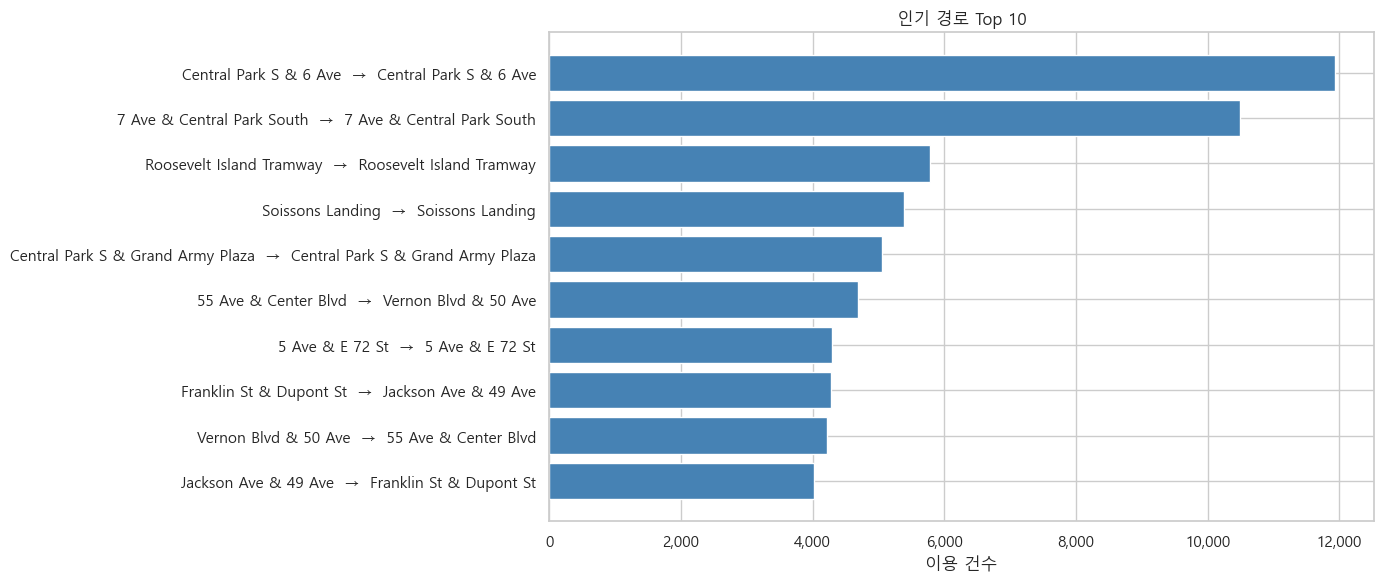

In [6]:
# ── 4. 인기 출발-도착 경로 Top 10 ───────────────────────────────────
route_cnt = (
    df.groupby(['start_station_name', 'end_station_name'])
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
)
route_cnt['route'] = route_cnt['start_station_name'] + '  →  ' + route_cnt['end_station_name']

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(route_cnt.head(10)['route'], route_cnt.head(10)['count'],
        color='steelblue', edgecolor='white')
ax.set_title('인기 경로 Top 10')
ax.set_xlabel('이용 건수')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

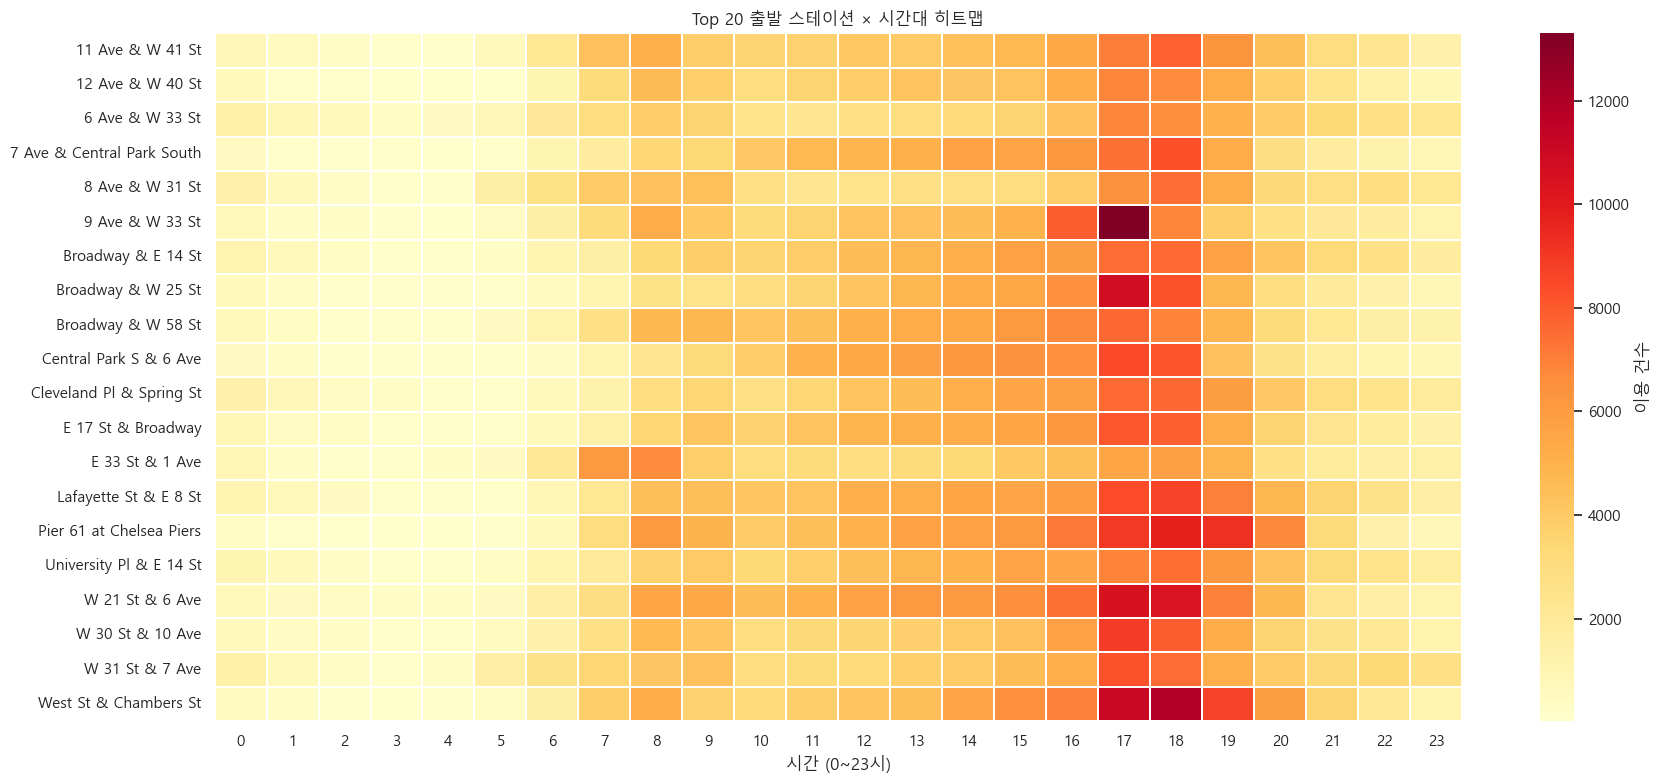

In [7]:
# ── 5. Top 20 스테이션 × 시간대 히트맵 ─────────────────────────────
top20 = start_cnt.head(20)['start_station_name'].tolist()

heatmap_data = (
    df[df['start_station_name'].isin(top20)]
    .assign(hour=df['started_at'].dt.hour)
    .groupby(['start_station_name', 'hour'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3,
            ax=ax, cbar_kws={'label': '이용 건수'})
ax.set_title('Top 20 출발 스테이션 × 시간대 히트맵')
ax.set_xlabel('시간 (0~23시)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

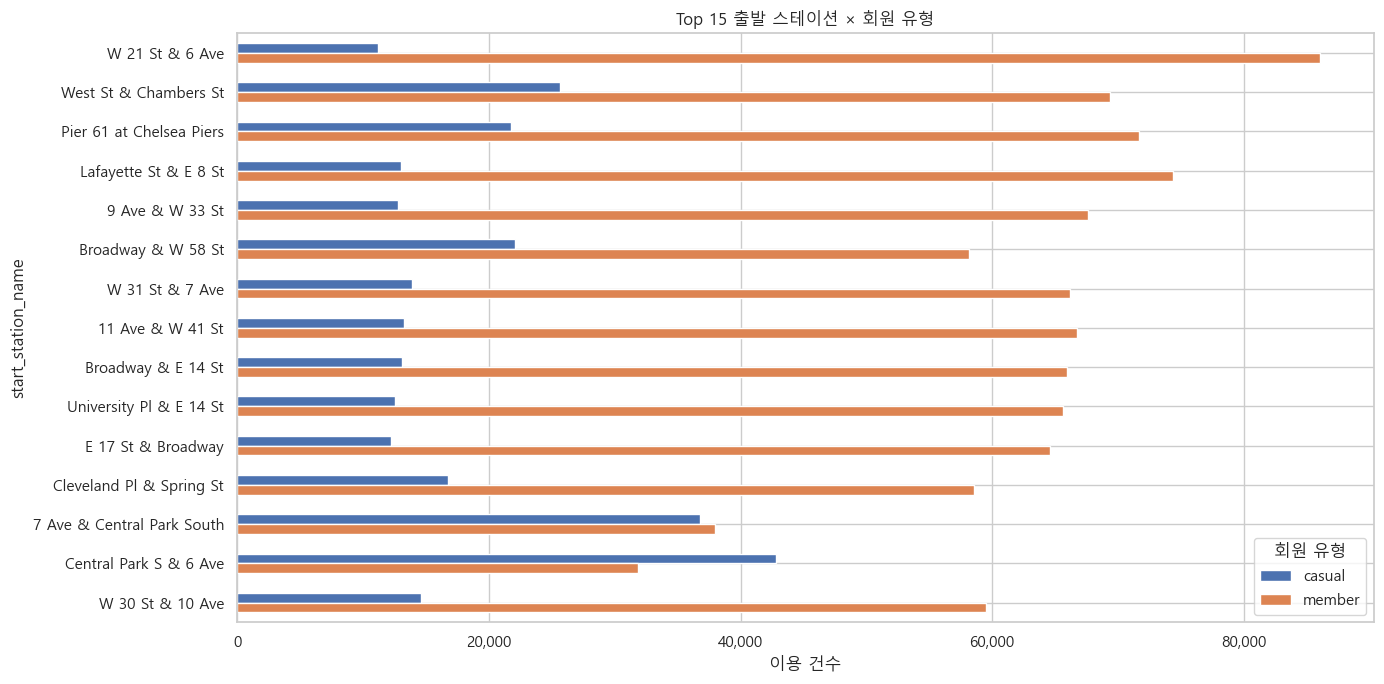

In [8]:
# ── 6. 회원 유형별 스테이션 이용 패턴 ───────────────────────────────
member_station = (
    df.groupby(['start_station_name', 'member_casual'])
      .size()
      .unstack(fill_value=0)
      .assign(total=lambda x: x.sum(axis=1))
      .sort_values('total', ascending=False)
      .head(15)
      .drop(columns='total')
)

member_station.plot(kind='barh', figsize=(14, 7), edgecolor='white')
plt.title('Top 15 출발 스테이션 × 회원 유형')
plt.xlabel('이용 건수')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='회원 유형')
plt.tight_layout()
plt.show()

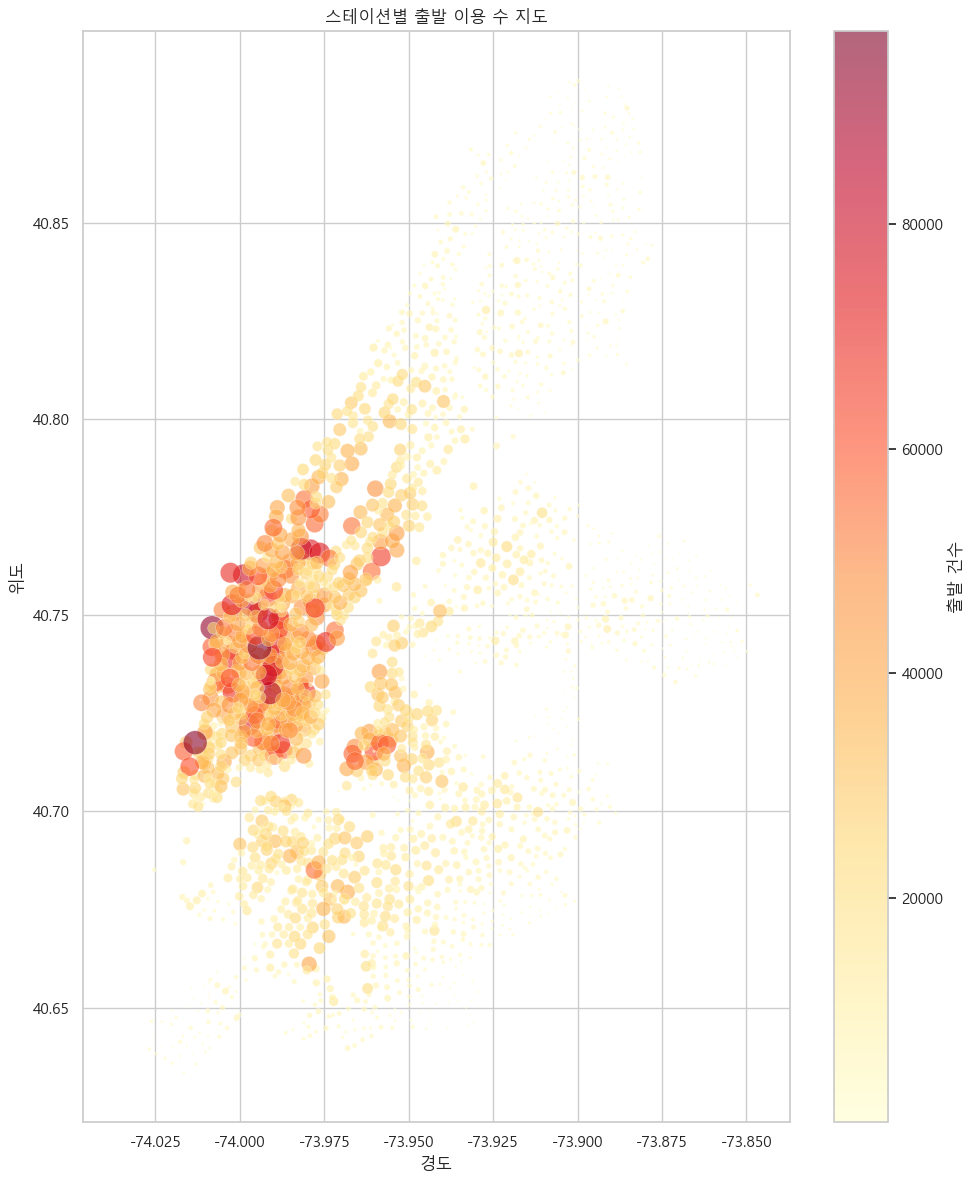

In [9]:
# ── 7. 스테이션 위치 산점도 (이용 수 크기 반영) ─────────────────────
station_geo = (
    df.groupby('start_station_name')
      .agg(lat=('start_lat', 'mean'),
           lng=('start_lng', 'mean'),
           count=('ride_id', 'count'))
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 12))
sc = ax.scatter(
    station_geo['lng'], station_geo['lat'],
    s=station_geo['count'] / station_geo['count'].max() * 300,
    c=station_geo['count'], cmap='YlOrRd',
    alpha=0.6, edgecolors='white', linewidths=0.3
)
plt.colorbar(sc, ax=ax, label='출발 건수')
ax.set_title('스테이션별 출발 이용 수 지도')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
plt.tight_layout()
plt.show()